# Etape 2.2 — Face Match : Selfie vs Photo ID

Ce notebook implémente la vérification biométrique entre un selfie et la photo extraite d'une pièce d'identité.

**Pipeline :**
1. La photo ID est fournie par l'étape 2.1 (crop du visage sur le document)
2. L'utilisateur fournit un selfie
3. YOLO détecte et recadre le visage dans le selfie
4. ArcFace extrait les embeddings des deux visages et calcule leur similarité
5. Résultat : MATCH ou NO MATCH

> Executer les cellules dans l'ordre, de haut en bas.

---
## 1. Installation des librairies

In [ ]:
# Toutes les dependances du projet
!pip install ultralytics insightface onnxruntime opencv-python-headless pillow pillow-heif huggingface_hub tqdm scikit-learn -q
print('Installation terminee.')

Installation terminee.


---
## 2. Imports

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener
from google.colab import files
from ultralytics import YOLO
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Support des photos iPhone (format HEIC)
register_heif_opener()

print('Imports OK.')

Imports OK.


---
## 3. Chargement des modeles

- **YOLOv8-Face** : detection du visage dans le selfie
- **ArcFace (buffalo_l)** : extraction des embeddings faciaux et comparaison

Le premier lancement telecharge automatiquement les poids (~300MB).

In [ ]:
from insightface.app import FaceAnalysis
from huggingface_hub import hf_hub_download

# Chargement de YOLO specialise detection de visages
print('Chargement de YOLO...')
chemin_yolo = hf_hub_download(
    repo_id='arnabdhar/YOLOv8-Face-Detection',
    filename='model.pt'
)
yolo_model = YOLO(chemin_yolo)
print('YOLO charge.')

# Chargement d'ArcFace via insightface (buffalo_l = ResNet50, 99.8% sur LFW)
print('Chargement d ArcFace (buffalo_l)...')
app_arcface = FaceAnalysis(
    name='buffalo_l',
    providers=['CPUExecutionProvider']  # remplacer par CUDAExecutionProvider si GPU disponible
)
app_arcface.prepare(ctx_id=-1, det_size=(640, 640))
print('ArcFace charge.')

Chargement de YOLO...
YOLO charge.
Chargement d ArcFace (buffalo_l)...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition 

---
## 4. Pretraitement des images

Fonction de normalisation appliquee a toutes les images avant traitement.
Gere : correction d'orientation EXIF, conversion de format, transparence, redimensionnement.

In [ ]:
TAILLE_MAX = 1920  # pixels, au-dela l'image est redimensionnee

def pretraiter_image(chemin_image: str) -> np.ndarray:
    """
    Charge et normalise une image pour YOLO et ArcFace.
    Retourne un tableau numpy BGR.
    """
    if not Path(chemin_image).exists():
        raise FileNotFoundError(f'Fichier introuvable : {chemin_image}')

    try:
        img_pil = Image.open(chemin_image)
    except Exception:
        raise ValueError('Image corrompue ou format non supporte.')

    # Correction de l'orientation (photos smartphone souvent mal orientees)
    img_pil = ImageOps.exif_transpose(img_pil)

    # Conversion en RGB 3 canaux selon le mode detecte
    if img_pil.mode == 'RGBA':
        # PNG avec transparence : fond transparent remplace par blanc
        fond_blanc = Image.new('RGB', img_pil.size, (255, 255, 255))
        fond_blanc.paste(img_pil, mask=img_pil.split()[3])
        img_pil = fond_blanc
    elif img_pil.mode in ('L', 'LA', 'P'):
        img_pil = img_pil.convert('RGB')
    else:
        img_pil = img_pil.convert('RGB')

    # Redimensionnement si l'image depasse la taille maximale
    if max(img_pil.size) > TAILLE_MAX:
        img_pil.thumbnail((TAILLE_MAX, TAILLE_MAX), Image.LANCZOS)

    # Conversion vers BGR (format attendu par OpenCV et YOLO)
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    return img_bgr

print('Fonction de pretraitement definie.')

Fonction de pretraitement definie.


---
## 5. Detection du visage (YOLO)

YOLO localise le visage dans une image et retourne uniquement la zone du visage.
Utilise pour recadrer le selfie avant extraction d'embedding.

In [ ]:
SEUIL_CONFIANCE_YOLO = 0.5   # confiance minimale pour valider une detection
TAILLE_MIN_VISAGE    = 60    # taille minimale en pixels pour qu'un visage soit exploitable

def detecter_visage_yolo(img_bgr: np.ndarray) -> np.ndarray:
    """
    Detecte le visage dans une image et retourne le crop du visage.
    Si plusieurs visages sont detectes, selectionne le plus grand.
    Retourne un tableau numpy BGR.
    """
    resultats   = yolo_model(img_bgr, conf=SEUIL_CONFIANCE_YOLO, verbose=False, device='cpu')
    boites      = resultats[0].boxes

    if boites is None or len(boites) == 0:
        raise ValueError('Aucun visage detecte. Verifier que le visage est bien visible et centre.')

    boites_xyxy = boites.xyxy.cpu().numpy()
    boites_conf = boites.conf.cpu().numpy()

    # Selection du visage le plus grand (supposé le plus proche de la camera)
    surfaces      = [(x2-x1)*(y2-y1) for x1,y1,x2,y2 in boites_xyxy]
    idx           = int(np.argmax(surfaces))
    x1,y1,x2,y2  = [int(v) for v in boites_xyxy[idx]]
    confiance     = float(boites_conf[idx])

    largeur = x2 - x1
    hauteur = y2 - y1

    if largeur < TAILLE_MIN_VISAGE or hauteur < TAILLE_MIN_VISAGE:
        raise ValueError(f'Visage trop petit ({largeur}x{hauteur}px). Rapprocher la camera.')

    # Marge de 20% autour du visage pour eviter de le couper
    h_img, w_img = img_bgr.shape[:2]
    x1 = max(0, x1 - int(largeur * 0.20))
    y1 = max(0, y1 - int(hauteur * 0.20))
    x2 = min(w_img, x2 + int(largeur * 0.20))
    y2 = min(h_img, y2 + int(hauteur * 0.20))

    print(f'Visage detecte | Confiance : {confiance:.2%} | Taille : {largeur}x{hauteur}px')
    return img_bgr[y1:y2, x1:x2]

print('Fonction de detection YOLO definie.')

Fonction de detection YOLO definie.


---
## 6. Extraction d'embedding ArcFace

ArcFace transforme un visage en un vecteur de 512 nombres (embedding) qui encode l'identite.
Deux visages de la meme personne produisent des embeddings proches.

In [ ]:
def extraire_embedding(img_bgr: np.ndarray) -> np.ndarray:
    """
    Detecte le visage dans l'image et extrait son embedding ArcFace.
    Retourne un vecteur numpy normalise de 512 dimensions.
    """
    faces = app_arcface.get(img_bgr)

    if not faces:
        raise ValueError('Aucun visage detecte pour l extraction d embedding.')

    # Si plusieurs visages, on prend celui avec le meilleur score de detection
    meilleur  = max(faces, key=lambda f: f.det_score)
    return meilleur.normed_embedding  # vecteur L2-normalise de 512 dimensions

print('Fonction d extraction ArcFace definie.')

Fonction d extraction ArcFace definie.


---
## 7. Comparaison et decision

La similarite entre deux embeddings est mesuree par la distance cosine.
- Distance proche de 0 : meme personne
- Distance proche de 2 : personnes differentes

**Deux seuils sont definis :**
- `SEUIL_DECISION` (0.40) : seuil strict utilise pour la demo KYC
- `SEUIL_EVALUATION` (0.70) : seuil optimal calibre par EER sur le dataset de test

In [ ]:
# Seuil strict pour la verification unitaire (demo KYC)
# A ce seuil, le systeme prefere rejeter une vraie personne plutot qu'accepter un imposteur
SEUIL_DECISION    = 0.40

# Seuil optimal calibre par EER sur le dataset Kaggle
SEUIL_EVALUATION  = 0.70

def comparer_visages(emb1: np.ndarray, emb2: np.ndarray, seuil: float = None) -> dict:
    """
    Compare deux embeddings ArcFace et retourne la decision.
    Retourne un dictionnaire avec : decision, score, distance, confiance.
    """
    seuil     = seuil or SEUIL_DECISION
    similarite = float(np.dot(emb1, emb2))       # produit scalaire = cosine similarity (embeddings L2-normalises)
    distance   = 1.0 - similarite                 # distance cosine [0, 2]
    score      = float(np.clip(similarite * 100, 0, 100))
    est_match  = distance < seuil

    # Niveau de confiance selon la marge au seuil
    marge = abs(distance - seuil)
    if marge >= 0.15:
        confiance = 'HAUTE'
    elif marge >= 0.05:
        confiance = 'MOYENNE'
    else:
        confiance = 'FAIBLE'

    return {
        'est_match' : est_match,
        'score'     : round(score, 1),
        'distance'  : round(distance, 4),
        'confiance' : confiance,
        'seuil'     : seuil
    }

print('Fonction de comparaison definie.')

Fonction de comparaison definie.


---
## 8. Affichage du resultat

In [ ]:
def afficher_resultat(img_selfie: np.ndarray, img_id: np.ndarray, resultat: dict):
    """
    Affiche les deux visages cote a cote avec le resultat de la comparaison.
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(cv2.cvtColor(img_selfie, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Selfie', fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(img_id, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Photo ID', fontsize=13, fontweight='bold')
    axes[1].axis('off')

    if resultat['est_match']:
        titre   = f"MEME PERSONNE - Score : {resultat['score']}% - Confiance : {resultat['confiance']}"
        couleur = '#1D9E75'
    else:
        titre   = f"PERSONNES DIFFERENTES - Score : {resultat['score']}% - Confiance : {resultat['confiance']}"
        couleur = '#D85A30'

    fig.suptitle(titre, fontsize=12, color=couleur, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*45}")
    print(f"  Resultat  : {'MATCH' if resultat['est_match'] else 'NO MATCH'}")
    print(f"  Score     : {resultat['score']}%")
    print(f"  Distance  : {resultat['distance']} (seuil : {resultat['seuil']})")
    print(f"  Confiance : {resultat['confiance']}")
    print(f"{'='*45}")

print('Fonction d affichage definie.')

Fonction d affichage definie.


---
## 9. Verification unitaire (demo KYC)

Uploader la photo ID fournie par l'etape 2.1, puis le selfie de l'utilisateur.
Le seuil strict `SEUIL_DECISION = 0.40` est applique.

Upload de la photo ID...


Saving Photo d’identité_page-0001.jpg to Photo d’identité_page-0001 (1).jpg
Upload du selfie...


Saving IMG_8436.jpeg to IMG_8436 (1).jpeg
Detection du visage dans le selfie...
Visage detecte | Confiance : 85.28% | Taille : 744x1108px
Detection du visage dans la photo ID...
Visage detecte | Confiance : 94.71% | Taille : 780x1091px
Extraction des embeddings ArcFace...


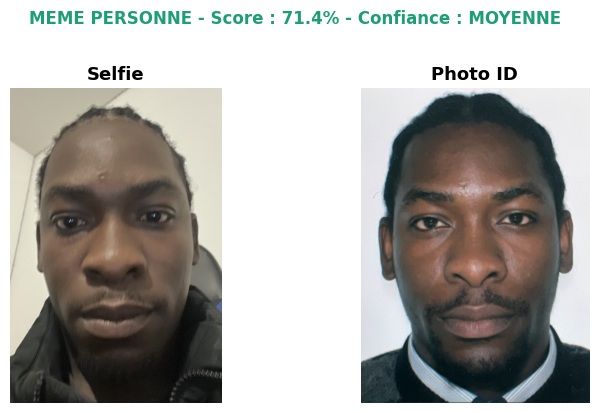


  Resultat  : MATCH
  Score     : 71.4%
  Distance  : 0.2862 (seuil : 0.4)
  Confiance : MOYENNE


In [ ]:
# Upload de la photo ID (crop fourni par l'etape 2.1)
print('Upload de la photo ID...')
fichiers_id     = files.upload()
chemin_photo_id = list(fichiers_id.keys())[0]

# Upload du selfie
print('Upload du selfie...')
fichiers_selfie = files.upload()
chemin_selfie   = list(fichiers_selfie.keys())[0]

# Pretraitement
img_id     = pretraiter_image(chemin_photo_id)
img_selfie = pretraiter_image(chemin_selfie)

# Detection du visage dans les deux images
print('Detection du visage dans le selfie...')
crop_selfie = detecter_visage_yolo(img_selfie)
print('Detection du visage dans la photo ID...')
crop_id     = detecter_visage_yolo(img_id)

# Extraction des embeddings
print('Extraction des embeddings ArcFace...')
emb_selfie = extraire_embedding(img_selfie)
emb_id     = extraire_embedding(img_id)

# Comparaison avec seuil strict KYC
resultat = comparer_visages(emb_selfie, emb_id, seuil=SEUIL_DECISION)
afficher_resultat(crop_selfie, crop_id, resultat)